In [1]:
%load_ext autoreload
import datetime as dt
import os
import sys
from itertools import product

import yaml

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from ipywidgets import interact
from scipy.signal import periodogram
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf

from src.data.download_yfinance import download_ticker_data

In [3]:
from src.pipeline.data_loader import DataLoader

loader = DataLoader(config_path="../config/tickers_list.yaml",
                    use_cache=False, 
                    verbose=True)

df_all = loader.load(start_date="2022-01-01", intervals=["1d"])

In [4]:
df_all['interval'].value_counts()

interval
1d    33284
Name: count, dtype: int64

### Load data

In [5]:
# declare period to load into notebook 
# Note: (yfinance will have freshest data every morning CEST)
params = {
    'start_date': '2022-01-01',
    'end_date': dt.datetime.today()
}

In [6]:
# declare tickers + tickers sanity test
with open("../config/tickers_list.yaml", "r") as f:
    tickers = yaml.safe_load(f)["tickers"]

tickers[:5]

['AAPL', 'MSFT', 'GDX', 'IONQ', '7974.T']

In [7]:
intervals = ["1d", "1wk", "1mo"]
all_dfs = []

for ticker, interval in product(tickers, intervals):
    _ = download_ticker_data(
        tickers=[ticker],
        start=params["start_date"],
        end=params["end_date"],
        interval=interval,
    )
    if _ is not None and not _.empty:
        _["ticker"] = ticker
        _["interval"] = interval
        all_dfs.append(_)

df_all = pd.concat(all_dfs)

### Create metrics by periods

In [8]:
seasonal_lags = {"1d": 252, "1wk": 52, "1mo": 12}
results = []

for (ticker, interval), df_group in df_all.groupby(["ticker", "interval"]):
    series = df_group["close"].dropna()
    lag = seasonal_lags[interval]

    if len(series) < lag + 10:
        continue

    # acf
    acf_vals = acf(series, nlags=lag + 10, fft=True)
    acf_lag_val = acf_vals[lag]

    # periodogram
    freqs, power = periodogram(series)
    mean_power = power.mean()
    p2m_val = power.max() / mean_power if mean_power > 0 else 0

    # stl
    try:
        stl = STL(series, period=lag, robust=True)
        stl_result = stl.fit()
        resid_var = np.var(stl_result.resid)
        season_plus_resid_var = np.var(stl_result.seasonal + stl_result.resid)
        stl_strength = (
            1 - resid_var / season_plus_resid_var 
            if season_plus_resid_var > 0 else 0
        )
    except Exception:
        stl_strength = np.nan 

    results.append({
        "ticker": ticker,
        "interval": interval,
        "acf_lag_val": acf_lag_val,
        "p2m_val": p2m_val,
        "stl_strength": stl_strength
    })

df_scores = pd.DataFrame(results)

### Normalize metrics and combine into metametric

In [9]:
df_scores_norm = []

for interval, df_group in df_scores.groupby("interval"):
    scaler = MinMaxScaler()
    df_scaled = df_group.copy()
    df_scaled[["acf_lag_val", "p2m_val", "stl_strength"]] = scaler.fit_transform(
        df_group[["acf_lag_val", "p2m_val", "stl_strength"]]
    )
    df_scores_norm.append(df_scaled)

df_scores_norm = pd.concat(df_scores_norm)

In [10]:
def add_seasonality_meta_scores(
    df: pd.DataFrame,
    metrics: list = ["acf_lag_val", "p2m_val", "stl_strength"],
    weights: list = None
) -> pd.DataFrame:
    """
    Add composite seasonality scores to the DataFrame using methods:
    
    - Linear combination: 
        - Simple weighted sum (default is equal weights)
        - This one's the easiest to tune with good interpretability
        - No imbalance penalties
    
    - Geometric mean:
        - Multiplies normalized scores, then takes weighted log-sum
        - Moderately penalizes if one metric is weak
        - Scale-insensitive but less tunable
    
    - Harmonic mean:
        - Strongly penalizes imbalance
        - Emphasizes tickers with consistently high metrics
        - Conservative but robust
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with normalized metric columns
    metrics : list of str
        Columns to include in the score
    weights : list of float or None
        Optional weights for each metric (must match length of metrics).
        Defaults to equal weights.

    Returns
    -------
    pd.DataFrame
        Original DataFrame with new columns:
            - seasonality_score_linear
            - seasonality_score_geom
            - seasonality_score_harmonic
    """
    df = df.copy()
    n = len(metrics)

    if weights is None:
        weights = [1 / n] * n
    if len(weights) != n:
        raise ValueError("Length of weights must match length of metrics")

    eps = 1e-6
    vals = df[metrics].clip(lower=eps)

    # linear score
    df["seasonality_score_linear"] = sum(w * vals[m] for w, m in zip(weights, metrics))

    # geometric score
    df["seasonality_score_geom"] = np.exp(
        sum(w * np.log(vals[m]) for w, m in zip(weights, metrics))
    )

    # harmonic score
    df["seasonality_score_harmonic"] = 1 / sum(
        w / vals[m] for w, m in zip(weights, metrics)
    )

    return df

In [11]:
df_scores_meta = add_seasonality_meta_scores(df_scores_norm)

In [12]:
df_scores_meta

,ticker,interval,acf_lag_val,p2m_val,stl_strength,seasonality_score_linear,seasonality_score_geom,seasonality_score_harmonic
0,7974.T,1d,0.714890,0.313166,0.649932,0.559329,0.525970,0.489346
3,AAPL,1d,0.961472,0.251555,0.804893,0.672640,0.579566,0.479406
6,AVAV,1d,0.827980,0.151430,0.910924,0.630112,0.485182,0.336729
9,BB,1d,0.426940,0.217008,0.293786,0.312578,0.300810,0.289737
12,BMBL,1d,0.869526,0.304961,0.601128,0.591872,0.542206,0.492393
...,...,...,...,...,...,...,...,...
80,SONM,1wk,0.667469,0.260843,0.310420,0.412910,0.378082,0.350739
83,SRFM,1wk,0.000000,0.119743,0.318385,0.146043,0.003366,0.000003
86,TIGR,1wk,0.565918,0.292472,0.535769,0.464720,0.445935,0.425372
89,TMC,1wk,0.294040,0.154762,0.653616,0.367472,0.309835,0.263333


### Dashboard

In [13]:
@interact(
    ticker=sorted(df_scores_meta["ticker"].unique()),
    interval=sorted(df_scores_meta["interval"].unique()),
    score=[
        "seasonality_score_linear", 
        "seasonality_score_geom", 
        "seasonality_score_harmonic"
    ]
)
def show_histogram(ticker, interval, score):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # subset
    df_subset = df_scores_meta[
        (df_scores_meta["ticker"] == ticker) & 
        (df_scores_meta["interval"] == interval)
    ]

    # fallback if too few entries
    if df_subset.empty or df_subset[score].isnull().all():
        print("No valid data for this combination.")
        return

    sns.histplot(
        data=df_scores_meta[df_scores_meta["interval"] == interval], 
        x=score, 
        element="step", 
        stat="density", 
        bins=30,
        label="All Tickers (interval)",
        color="gray",
        ax=ax
    )

    sns.histplot(
        data=df_subset, 
        x=score, 
        element="step", 
        stat="density", 
        bins=30,
        label=f"{ticker}",
        color="orange",
        ax=ax
    )

    ax.set_xlim(0, 1)
    ax.set_title(
        f"Histogram of {score.replace('_', ' ').title()} — {ticker} @ {interval}"
    )
    ax.legend()
    plt.show()

interactive(children=(Dropdown(description='ticker', options=('7974.T', 'AAPL', 'AVAV', 'BB', 'BMBL', 'CGW', '…

## Basic stats

In [14]:
df_scores_meta[[
    "seasonality_score_linear", 
    "seasonality_score_geom", 
    "seasonality_score_harmonic"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
seasonality_score_linear,93.0,0.462655,0.161235,0.113322,0.343071,0.434692,0.589295,0.811442
seasonality_score_geom,93.0,0.388309,0.194376,0.003032,0.272007,0.393200,0.530848,0.801165
seasonality_score_harmonic,93.0,0.343344,0.190576,0.000003,0.250808,0.350739,0.479406,0.791720


Note: All 3 metrics seem to show variation across ticker/interval landscape. Ranges also show not all tickers behave the same, which is a precondition to make sure the alternative hypothesis stands. Meaningful identification of seasonality is key here. 
- Linear mean at $~0.5$ suggests most stocks have moderate levels of seasonal signal across fundamental metrics $ACF, P2M, STL$.
      - Seasonality is present but not overwhelming across board
- Geometric/Harmonic scores are lower seems like a good sign, as they'd be successfully penalizing noise or partial structure (when one or two components dominate)
      - Harmonic specially, its scores near 0 suggest it's doing the job of filtering weak, inconsistent patterns.  

### Boxplots

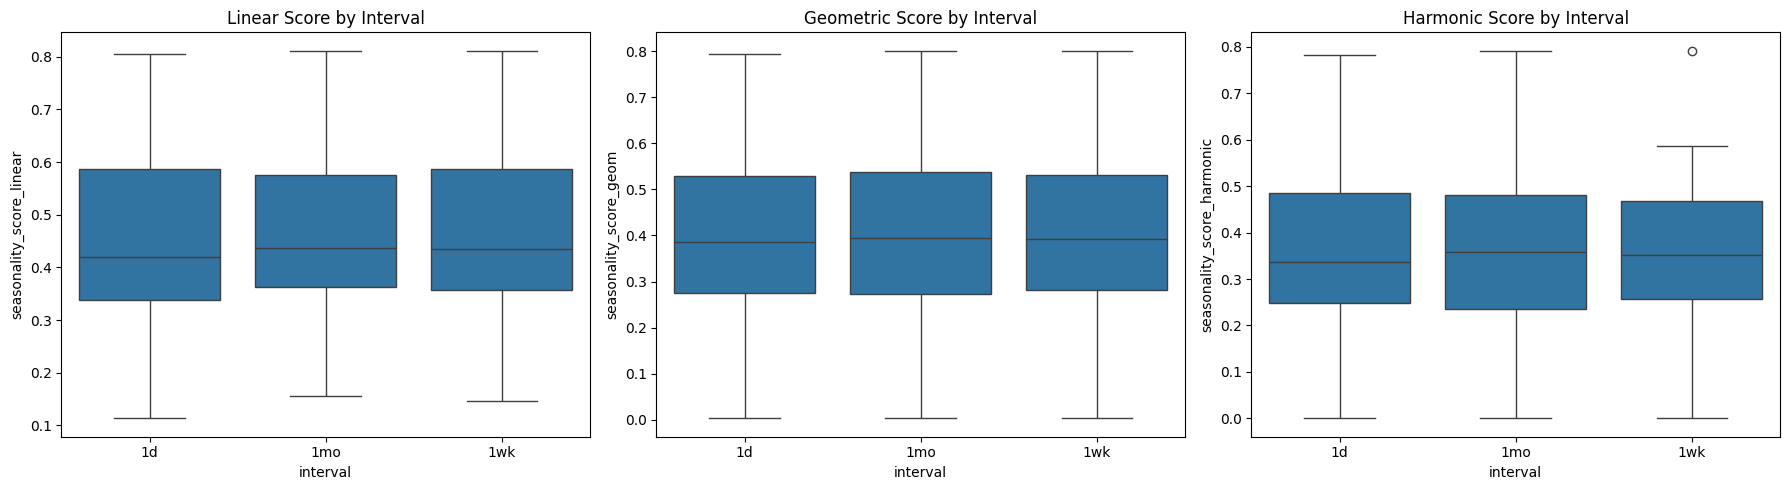

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df_scores_meta, 
    x="interval", 
    y="seasonality_score_linear", 
    ax=axs[0]
)
axs[0].set_title("Linear Score by Interval")

sns.boxplot(
    data=df_scores_meta, 
    x="interval", 
    y="seasonality_score_geom", 
    ax=axs[1]
)
axs[1].set_title("Geometric Score by Interval")

sns.boxplot(
    data=df_scores_meta, 
    x="interval", 
    y="seasonality_score_harmonic", 
    ax=axs[2]
)
axs[2].set_title("Harmonic Score by Interval")

plt.tight_layout()
plt.show()

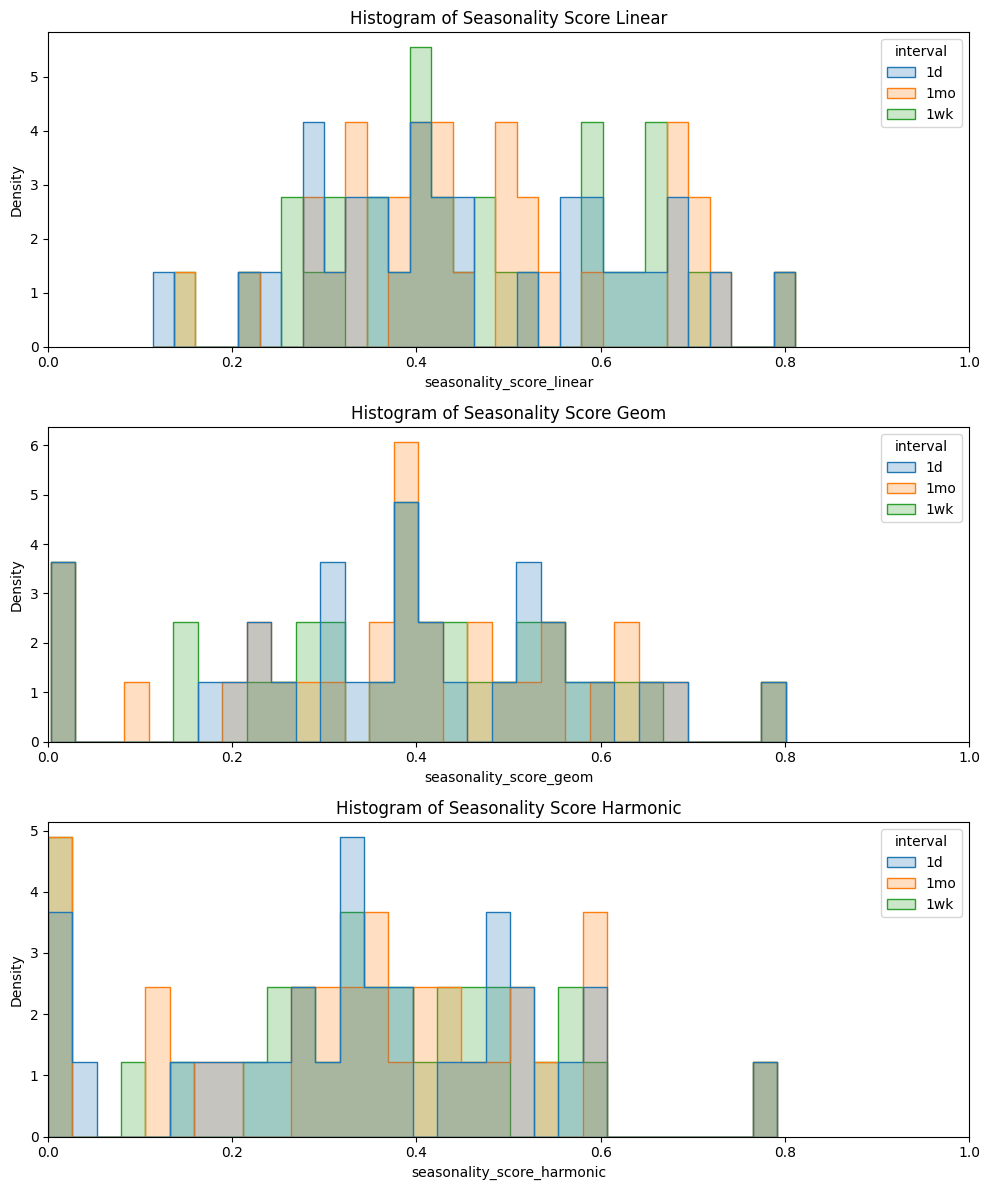

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

for i, score in enumerate([
    "seasonality_score_linear", 
    "seasonality_score_geom", 
    "seasonality_score_harmonic"
]):
    sns.histplot(
        data=df_scores_meta, 
        x=score, 
        hue="interval", 
        element="step", 
        stat="density", 
        common_norm=False,
        ax=axs[i],
        bins=30
    )
    axs[i].set_title(
        f"Histogram of {score.replace('_', ' ').title()}"
    )
    axs[i].set_xlim(0, 1)

plt.tight_layout()
plt.show()